# London Gift Shop Customer Segmentation PoC

## RFM Analysis for Targeted Marketing Campaigns

**Client:** London Gift Shop (LGS)  
**Role:** Data Engineer / Analytics PoC Developer  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

---

## Executive Summary

London Gift Shop has operated online for more than 10 years, but revenue growth has slowed. The goal of this PoC is to help the marketing team understand customer shopping behaviour and create targeted marketing strategies.

This notebook transforms raw transaction data into customer-level insights using **RFM analysis**:

- **Recency:** How recently a customer purchased
- **Frequency:** How often a customer purchased
- **Monetary:** How much a customer spent

The output is a customer segmentation framework that identifies high-value customers, loyal customers, new customers, at-risk customers, and lost customers. These segments can be used by the LGS marketing team for email campaigns, promotions, events, and customer retention strategies.

## 1. Business Problem

LGS wants to improve revenue growth by understanding customer behaviour. Since the marketing team does not have internal IT capability, this PoC provides a simple, repeatable analytics workflow using Python and Jupyter Notebook.

### Key Business Questions

1. Which customers are most valuable to LGS?
2. Which customers are loyal and purchase frequently?
3. Which customers are at risk of churn?
4. Which countries generate the most revenue?
5. What targeted marketing actions should LGS take for each customer segment?

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Default visual settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Load Data

The source file contains transaction data from 01/12/2009 to 09/12/2011. Personal customer information was removed during the ETL process.

In [2]:
# Load dataset
DATA_PATH = 'online_retail_II.csv'

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    # Fallback path for local execution from /mnt/data
    df = pd.read_csv('/content/online_retail_II.csv')

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


## 3. Data Overview

Before building customer segments, we inspect the dataset structure, missing values, duplicate records, and basic transaction statistics.

In [3]:
# Standardize column names for cleaner analysis
rename_map = {
    'Invoice': 'invoice_no',
    'StockCode': 'stock_code',
    'Description': 'description',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date',
    'Price': 'unit_price',
    'Customer ID': 'customer_id',
    'Country': 'country'
}

df = df.rename(columns=rename_map)
df.columns

Index(['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'customer_id', 'country'],
      dtype='object')

In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   invoice_no    1067371 non-null  object 
 1   stock_code    1067371 non-null  object 
 2   description   1062989 non-null  object 
 3   quantity      1067371 non-null  int64  
 4   invoice_date  1067371 non-null  object 
 5   unit_price    1067371 non-null  float64
 6   customer_id   824364 non-null   float64
 7   country       1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
# Missing values summary
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_count', ascending=False)

missing_summary

,missing_count,missing_percent
customer_id,243007,22.77
description,4382,0.41
stock_code,0,0.00
invoice_no,0,0.00
quantity,0,0.00
invoice_date,0,0.00
unit_price,0,0.00
country,0,0.00


In [6]:
# Basic numerical summary
df[['quantity', 'unit_price']].describe()

,quantity,unit_price
count,"1,067,371.00","1,067,371.00"
mean,9.94,4.65
std,172.71,123.55
min,"-80,995.00","-53,594.36"
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.15
max,"80,995.00","38,970.00"


In [7]:
# Duplicate rows count
duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)

Duplicate rows: 34335


## 4. Data Cleaning

Cleaning rules applied:

1. Remove rows with missing customer IDs because RFM analysis requires customer-level grouping.
2. Remove cancelled invoices where invoice number starts with `C`.
3. Remove negative or zero quantity values.
4. Remove zero or negative unit prices.
5. Remove duplicate rows.
6. Convert invoice date to datetime.
7. Create total transaction value.

These steps ensure that customer segmentation is based on valid completed sales transactions.

In [8]:
# Create a working copy
retail = df.copy()

# Convert invoice number to string
retail['invoice_no'] = retail['invoice_no'].astype(str)

# Convert invoice date
retail['invoice_date'] = pd.to_datetime(retail['invoice_date'])

# Remove missing customer IDs
retail = retail.dropna(subset=['customer_id'])

# Convert customer ID to integer/string format
retail['customer_id'] = retail['customer_id'].astype(int).astype(str)

# Remove cancelled invoices
retail = retail[~retail['invoice_no'].str.startswith('C')]

# Remove invalid quantity and price records
retail = retail[(retail['quantity'] > 0) & (retail['unit_price'] > 0)]

# Remove duplicates
retail = retail.drop_duplicates()

# Create total sales column
retail['total_price'] = retail['quantity'] * retail['unit_price']

print('Cleaned dataset shape:', retail.shape)
retail.head()

Cleaned dataset shape: (779425, 9)


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00


In [9]:
# Validate cleaned data
cleaning_validation = {
    'missing_customer_ids': retail['customer_id'].isnull().sum(),
    'cancelled_invoices': retail['invoice_no'].str.startswith('C').sum(),
    'non_positive_quantity': (retail['quantity'] <= 0).sum(),
    'non_positive_unit_price': (retail['unit_price'] <= 0).sum(),
    'duplicate_rows': retail.duplicated().sum()
}

cleaning_validation

{'missing_customer_ids': np.int64(0),
 'cancelled_invoices': np.int64(0),
 'non_positive_quantity': np.int64(0),
 'non_positive_unit_price': np.int64(0),
 'duplicate_rows': np.int64(0)}

## 5. Exploratory Data Analysis

This section provides a business overview of sales, customers, products, and countries before customer segmentation.

In [10]:
# High-level KPIs
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Transactions',
        'Unique Customers',
        'Unique Products',
        'Countries',
        'Average Order Value'
    ],
    'Value': [
        retail['total_price'].sum(),
        retail['invoice_no'].nunique(),
        retail['customer_id'].nunique(),
        retail['stock_code'].nunique(),
        retail['country'].nunique(),
        retail.groupby('invoice_no')['total_price'].sum().mean()
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,"17,374,804.27"
1,Total Transactions,"36,969.00"
2,Unique Customers,"5,878.00"
3,Unique Products,"4,631.00"
4,Countries,41.00
5,Average Order Value,469.98


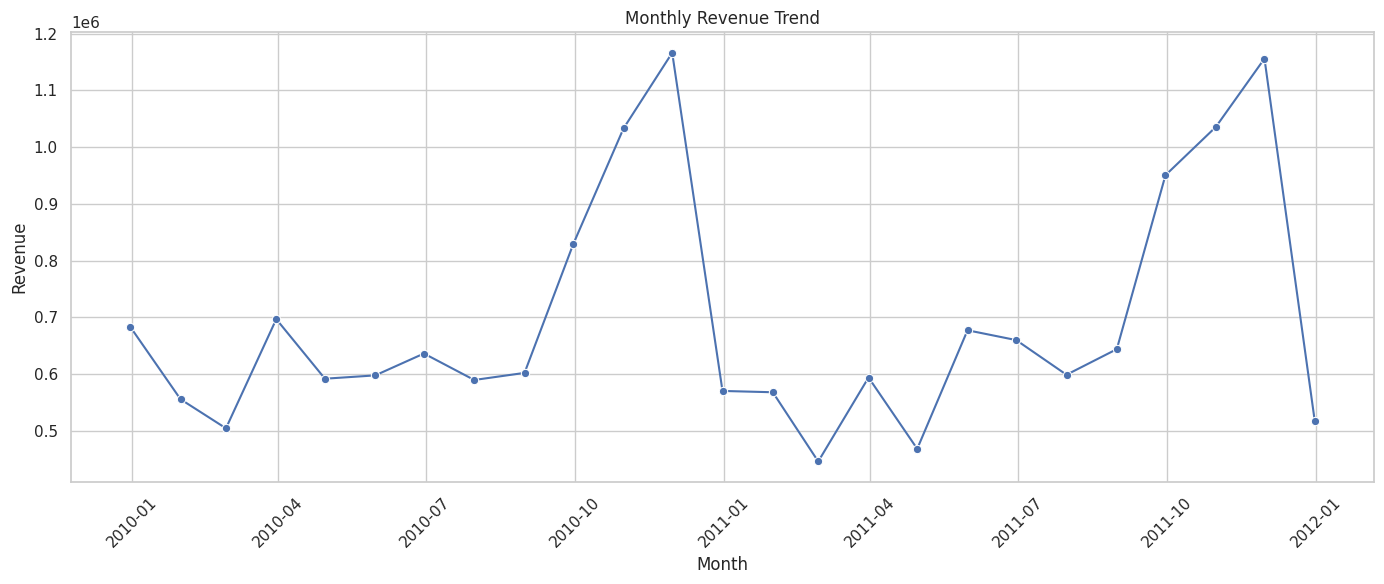

In [11]:
# Monthly revenue trend
monthly_revenue = retail.set_index('invoice_date').resample('M')['total_price'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x='invoice_date', y='total_price', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight: Revenue Trend

Monthly revenue helps LGS identify seasonality and campaign timing. Giftware businesses often experience stronger demand around holiday periods, so revenue spikes can guide campaign planning and inventory preparation.

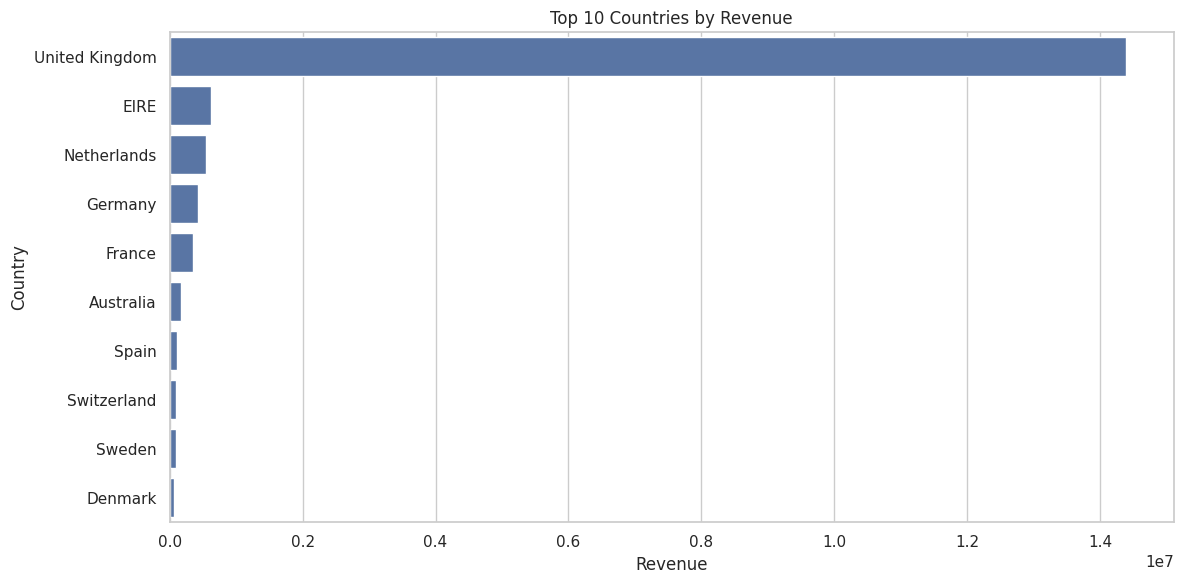

,country,total_price
0,United Kingdom,"14,389,234.92"
1,EIRE,"616,570.54"
2,Netherlands,"554,038.09"
3,Germany,"425,019.71"
4,France,"348,768.96"
5,Australia,"169,283.46"
6,Spain,"108,332.49"
7,Switzerland,"100,061.94"
8,Sweden,"91,515.82"
9,Denmark,"68,580.69"


In [12]:
# Top 10 countries by revenue
country_revenue = (
    retail.groupby('country')['total_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=country_revenue, x='total_price', y='country')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

country_revenue

### Insight: Geographic Revenue Concentration

Revenue is highly concentrated in the top countries, especially the United Kingdom. LGS should protect its core UK customer base while testing targeted campaigns in high-performing international markets.

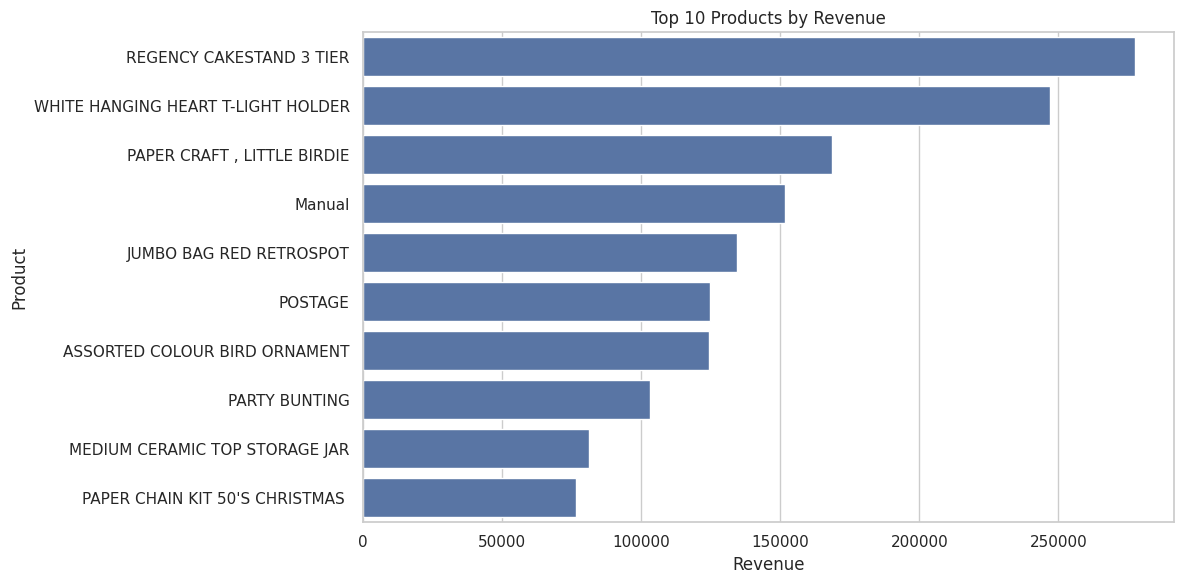

,stock_code,description,total_price
0,22423,REGENCY CAKESTAND 3 TIER,"277,656.25"
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"247,048.01"
2,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60"
3,M,Manual,"151,777.67"
4,85099B,JUMBO BAG RED RETROSPOT,"134,307.44"
5,POST,POSTAGE,"124,648.04"
6,84879,ASSORTED COLOUR BIRD ORNAMENT,"124,351.86"
7,47566,PARTY BUNTING,"103,283.38"
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73"
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"76,598.18"


In [13]:
# Top products by revenue
top_products = (
    retail.groupby(['stock_code', 'description'])['total_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x='total_price', y='description')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

top_products

### Insight: Product Revenue Drivers

Top revenue-generating products can be used in bundle offers, wholesale promotions, and seasonal campaigns. These products are strong candidates for email promotions to loyal and high-value customers.

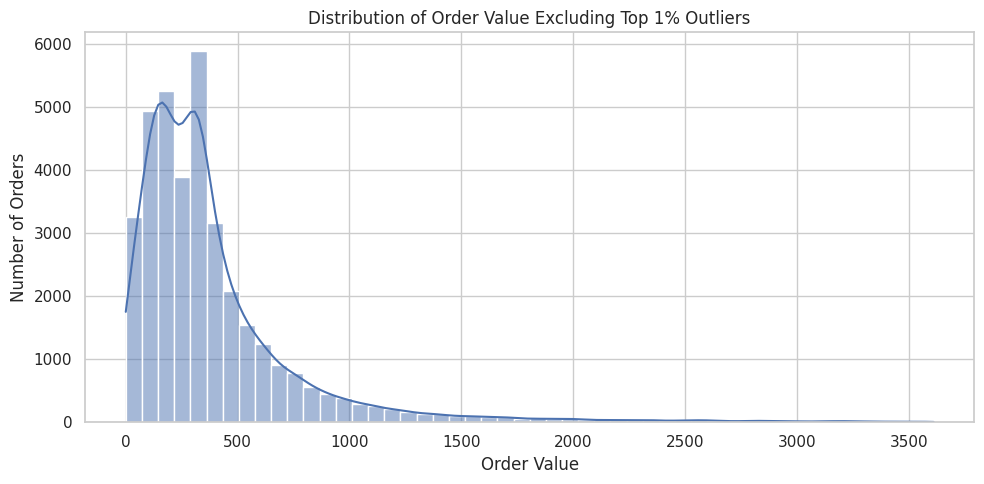

In [14]:
# Distribution of order values
invoice_value = retail.groupby('invoice_no')['total_price'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.histplot(invoice_value[invoice_value['total_price'] < invoice_value['total_price'].quantile(0.99)]['total_price'], bins=50, kde=True)
plt.title('Distribution of Order Value Excluding Top 1% Outliers')
plt.xlabel('Order Value')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

## 6. RFM Feature Engineering

RFM analysis converts transaction data into customer-level features.

- **Recency:** Number of days since the customer's most recent purchase. Lower recency means the customer purchased more recently.
- **Frequency:** Number of unique invoices for the customer.
- **Monetary:** Total revenue generated by the customer.

A snapshot date is set as one day after the latest invoice date in the dataset.

In [15]:
import datetime as dt

snapshot_date = retail['invoice_date'].max() + dt.timedelta(days=1)
print('Snapshot date:', snapshot_date)

rfm = retail.groupby('customer_id').agg({
    'invoice_date': lambda x: (snapshot_date - x.max()).days,
    'invoice_no': 'nunique',
    'total_price': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

rfm.head()

Snapshot date: 2011-12-10 12:50:00


,customer_id,recency,frequency,monetary
0,12346,326,12,"77,556.46"
1,12347,2,8,"4,921.53"
2,12348,75,5,"2,019.40"
3,12349,19,4,"4,428.69"
4,12350,310,1,334.40


In [16]:
# RFM descriptive statistics
rfm[['recency', 'frequency', 'monetary']].describe()

,recency,frequency,monetary
count,"5,878.00","5,878.00","5,878.00"
mean,201.33,6.29,"2,955.90"
std,209.34,13.01,"14,440.85"
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,"2,248.30"
max,739.00,398.00,"580,987.04"


## 7. RFM Distributions

The following visuals help identify customer behaviour patterns and outliers.

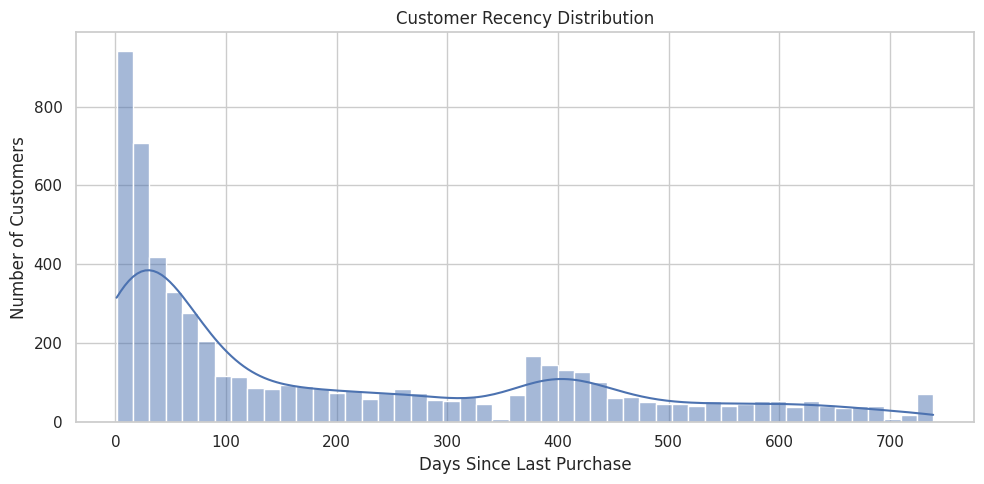

In [17]:
# Recency distribution
plt.figure(figsize=(10, 5))
sns.histplot(rfm['recency'], bins=50, kde=True)
plt.title('Customer Recency Distribution')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

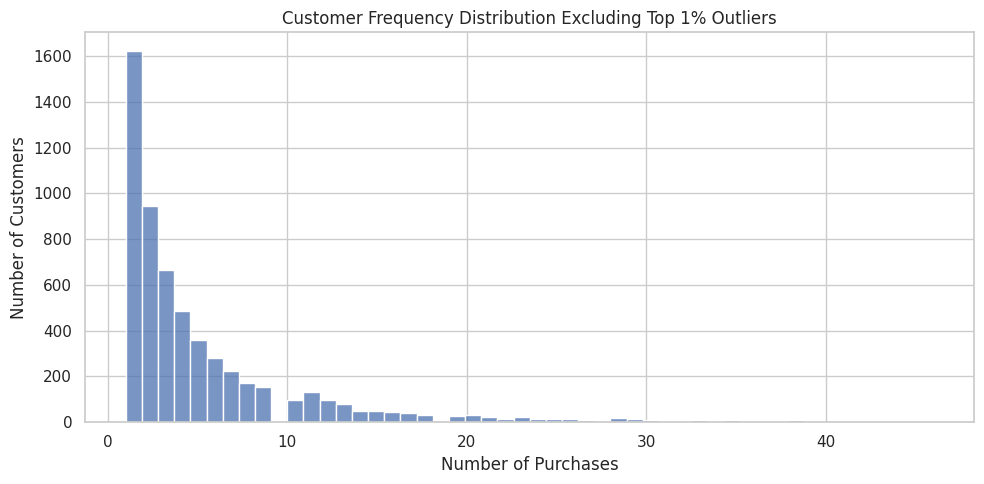

In [18]:
# Frequency distribution with outlier control
plt.figure(figsize=(10, 5))
freq_cap = rfm['frequency'].quantile(0.99)
sns.histplot(rfm[rfm['frequency'] <= freq_cap]['frequency'], bins=50, kde=False)
plt.title('Customer Frequency Distribution Excluding Top 1% Outliers')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

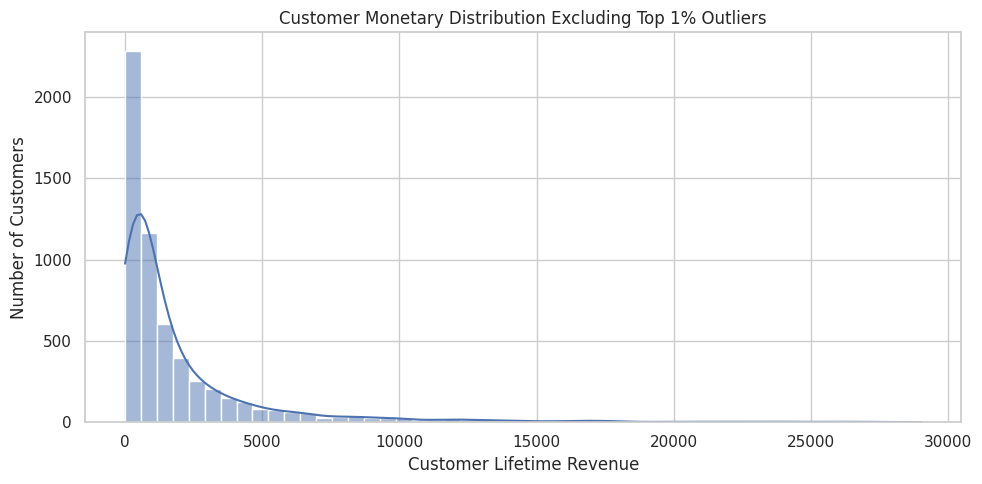

In [19]:
# Monetary distribution with outlier control
plt.figure(figsize=(10, 5))
monetary_cap = rfm['monetary'].quantile(0.99)
sns.histplot(rfm[rfm['monetary'] <= monetary_cap]['monetary'], bins=50, kde=True)
plt.title('Customer Monetary Distribution Excluding Top 1% Outliers')
plt.xlabel('Customer Lifetime Revenue')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Insight: Customer Value Distribution

Customer spend is not evenly distributed. A smaller group of customers contributes a much larger share of revenue. This supports the need for targeted marketing instead of one-size-fits-all promotions.

## 8. RFM Scoring

Each customer receives a score from 1 to 5 for recency, frequency, and monetary value.

- For **recency**, lower days since last purchase is better, so recent customers get a higher score.
- For **frequency**, more purchases is better.
- For **monetary**, higher spend is better.

In [20]:
# Create RFM scores using quantiles
# rank(method='first') avoids qcut issues when many customers have the same frequency
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
rfm['rfm_total_score'] = rfm[['r_score', 'f_score', 'm_score']].sum(axis=1)

rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score
0,12346,326,12,"77,556.46",2,5,5,255,12
1,12347,2,8,"4,921.53",5,4,5,545,14
2,12348,75,5,"2,019.40",3,4,4,344,11
3,12349,19,4,"4,428.69",5,3,5,535,13
4,12350,310,1,334.40,2,1,2,212,5


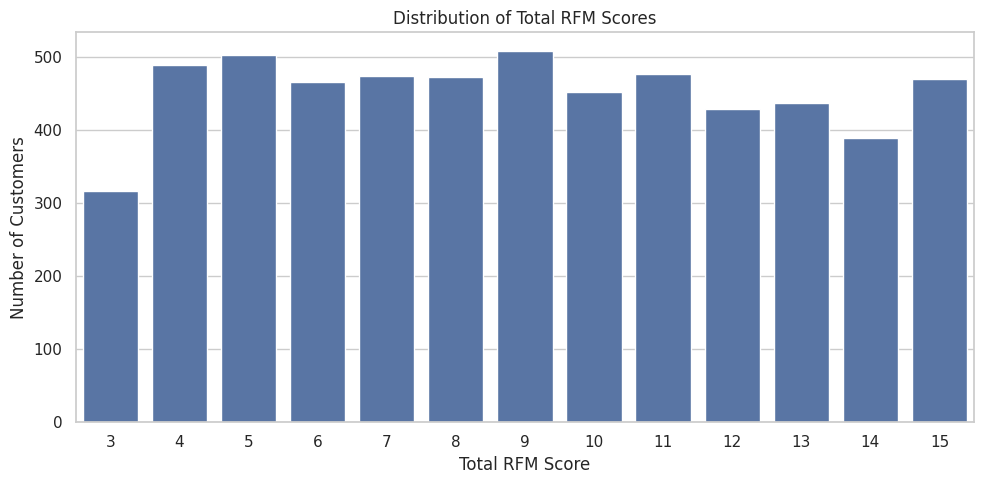

In [21]:
# RFM total score distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, x='rfm_total_score')
plt.title('Distribution of Total RFM Scores')
plt.xlabel('Total RFM Score')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

## 9. Customer Segmentation

Customers are mapped into actionable business segments using their RFM scores.

### Segment Definitions

| Segment | Business Meaning | Suggested Action |
|---|---|---|
| Champions | Recent, frequent, high-spending customers | VIP rewards and early access |
| Loyal Customers | Frequent repeat buyers | Cross-sell and bundle promotions |
| Potential Loyalists | Recent customers with moderate purchase behaviour | Nurture with personalized offers |
| New Customers | Recently acquired customers | Welcome campaigns |
| At Risk | Previously active but not recent | Re-engagement campaigns |
| Lost Customers | Low recency, frequency, and monetary value | Win-back campaigns |

In [22]:
# Customer segmentation logic
def assign_segment(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif f >= 4 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Need Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)
rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score,segment
0,12346,326,12,"77,556.46",2,5,5,255,12,Loyal Customers
1,12347,2,8,"4,921.53",5,4,5,545,14,Champions
2,12348,75,5,"2,019.40",3,4,4,344,11,Loyal Customers
3,12349,19,4,"4,428.69",5,3,5,535,13,Potential Loyalists
4,12350,310,1,334.40,2,1,2,212,5,Lost Customers


In [23]:
# Segment summary
segment_summary = rfm.groupby('segment').agg(
    customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).reset_index()

segment_summary['customer_percent'] = (segment_summary['customers'] / segment_summary['customers'].sum() * 100).round(2)
segment_summary['revenue_percent'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100).round(2)
segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

segment_summary

,segment,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,customer_percent,revenue_percent
1,Champions,1297,19.96,17.11,"9,143.86","11,859,591.49",22.07,68.26
3,Loyal Customers,977,170.72,7.90,"2,981.97","2,913,381.47",16.62,16.77
6,Potential Loyalists,633,25.35,2.80,"1,274.67","806,864.94",10.77,4.64
2,Lost Customers,1523,459.28,1.25,429.70,"654,426.70",25.91,3.77
4,Need Attention,714,105.84,2.24,787.73,"562,438.05",12.15,3.24
0,At Risk,497,387.80,3.07,"1,025.81","509,829.31",8.46,2.93
5,New Customers,237,29.17,1.12,288.07,"68,272.30",4.03,0.39


## 10. Customer Segment Visualizations

These visuals translate the RFM model into business-friendly insights for the LGS marketing team.

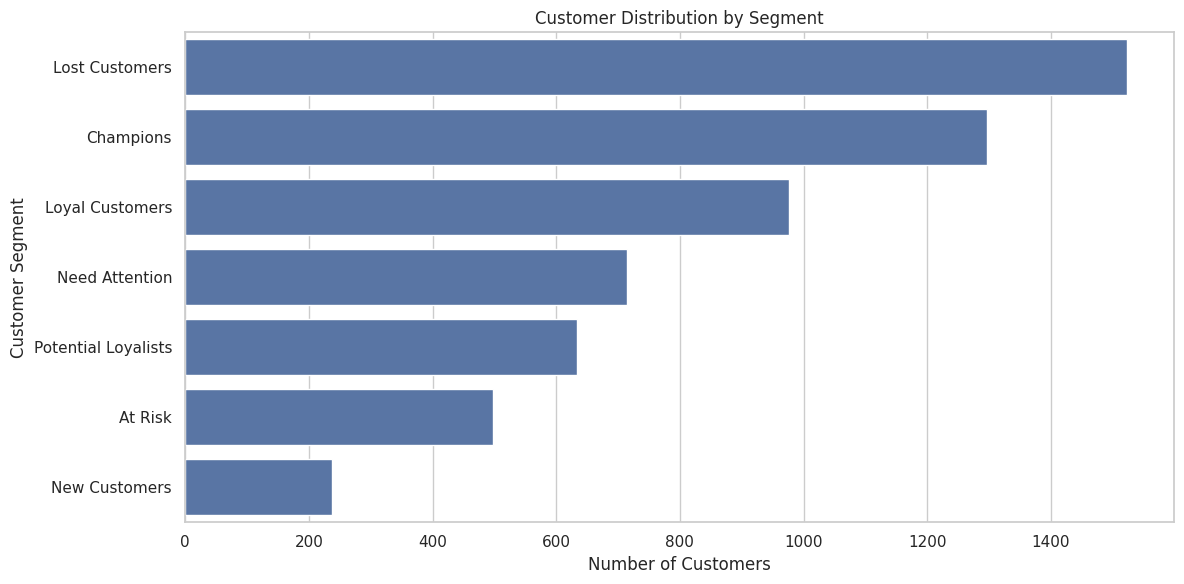

In [24]:
# Customer distribution by segment
segment_order = segment_summary.sort_values('customers', ascending=False)['segment']

plt.figure(figsize=(12, 6))
sns.countplot(data=rfm, y='segment', order=segment_order)
plt.title('Customer Distribution by Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

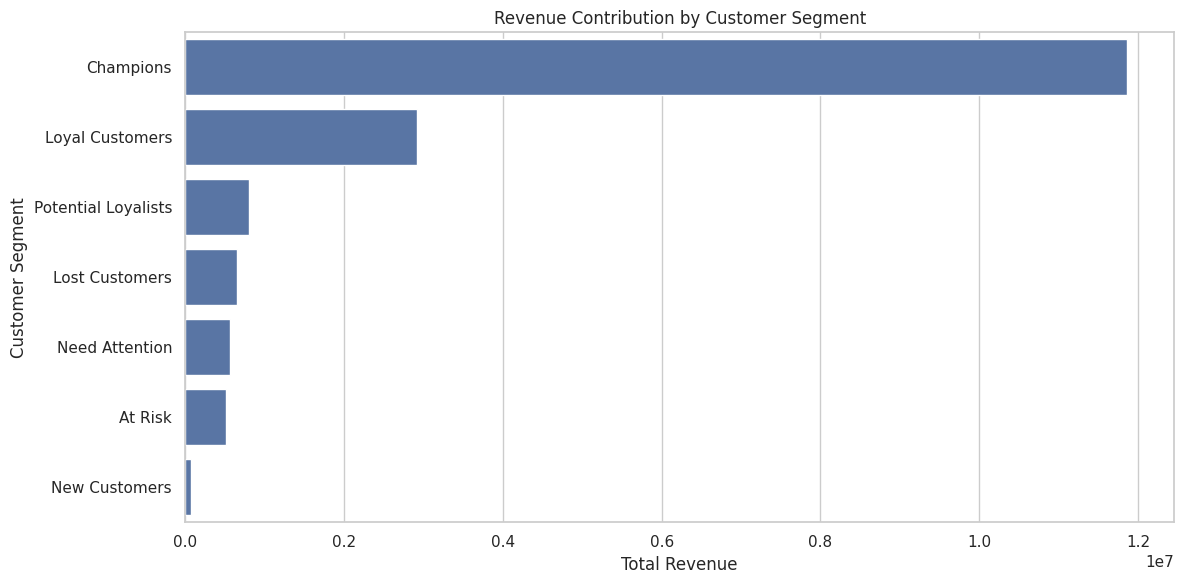

In [25]:
# Revenue by segment
plt.figure(figsize=(12, 6))
sns.barplot(data=segment_summary, x='total_revenue', y='segment')
plt.title('Revenue Contribution by Customer Segment')
plt.xlabel('Total Revenue')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

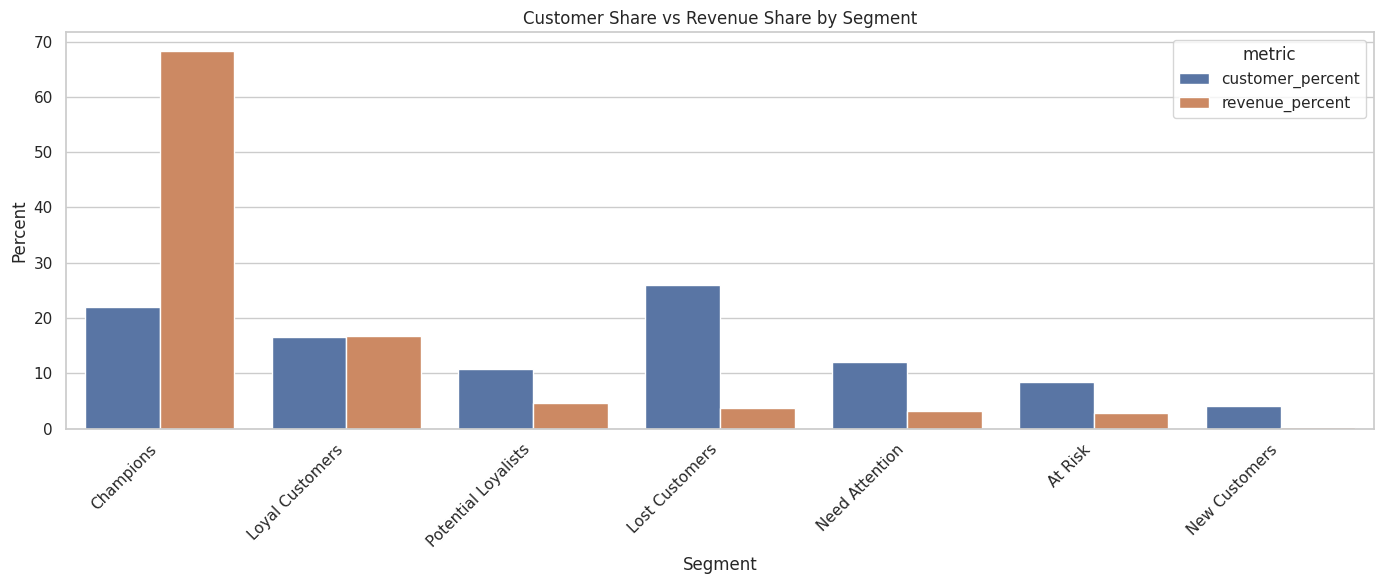

In [26]:
# Customer share vs revenue share
share_df = segment_summary[['segment', 'customer_percent', 'revenue_percent']].melt(
    id_vars='segment',
    value_vars=['customer_percent', 'revenue_percent'],
    var_name='metric',
    value_name='percent'
)

plt.figure(figsize=(14, 6))
sns.barplot(data=share_df, x='segment', y='percent', hue='metric')
plt.title('Customer Share vs Revenue Share by Segment')
plt.xlabel('Segment')
plt.ylabel('Percent')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

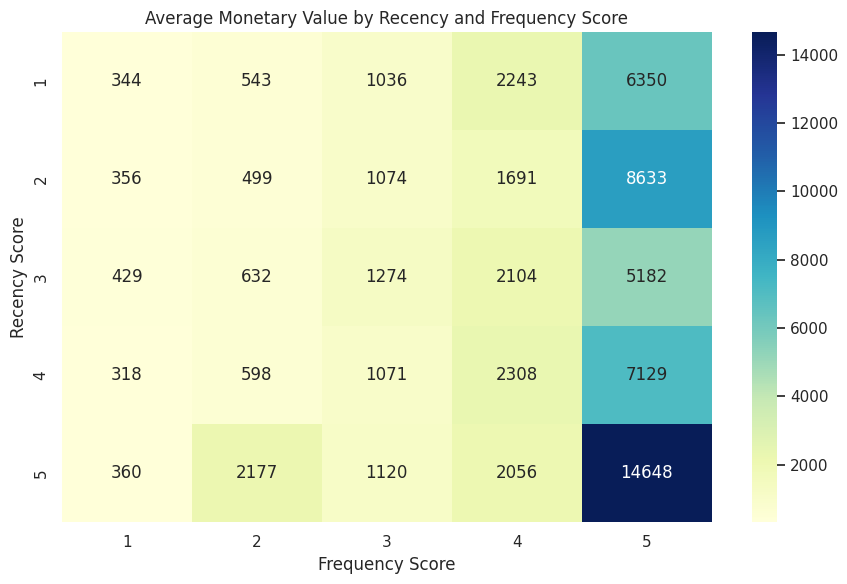

In [27]:
# RFM heatmap: average monetary value by recency and frequency score
rfm_heatmap = rfm.pivot_table(
    index='r_score',
    columns='f_score',
    values='monetary',
    aggfunc='mean'
)

plt.figure(figsize=(9, 6))
sns.heatmap(rfm_heatmap, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Monetary Value by Recency and Frequency Score')
plt.xlabel('Frequency Score')
plt.ylabel('Recency Score')
plt.tight_layout()
plt.show()

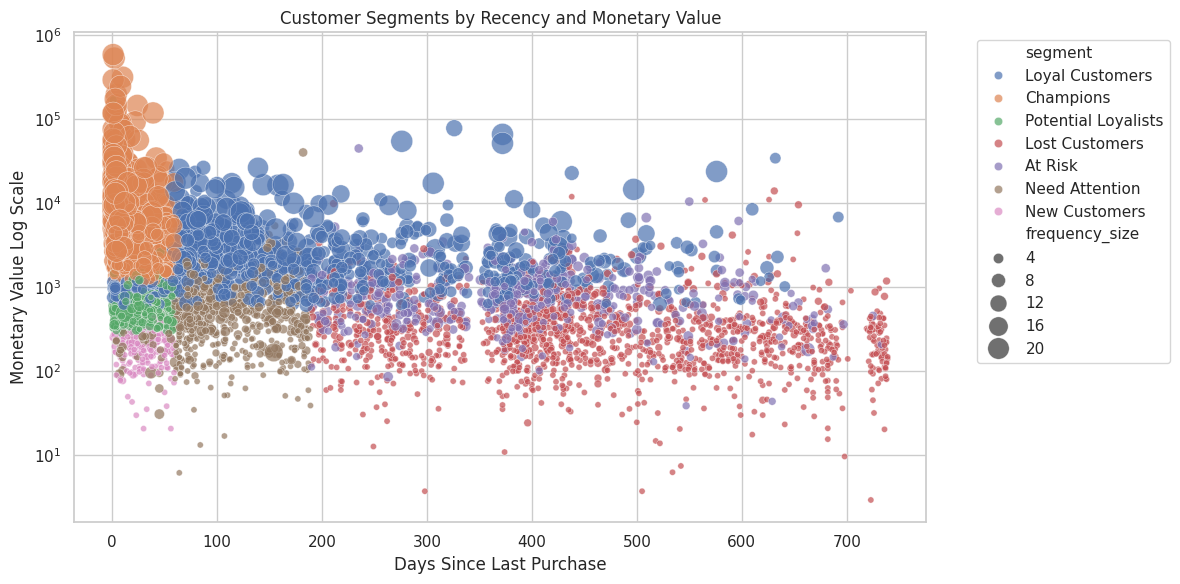

In [28]:
# Scatter plot: recency vs monetary, sized by frequency
plot_sample = rfm.copy()
plot_sample['frequency_size'] = np.clip(plot_sample['frequency'], 1, plot_sample['frequency'].quantile(0.95))

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=plot_sample,
    x='recency',
    y='monetary',
    hue='segment',
    size='frequency_size',
    sizes=(20, 250),
    alpha=0.7
)
plt.yscale('log')
plt.title('Customer Segments by Recency and Monetary Value')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Monetary Value Log Scale')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Insight 1: Revenue Concentration

Champions and Loyal Customers usually represent a smaller portion of the customer base but contribute a disproportionately high share of revenue. This means LGS should protect these relationships through loyalty programs, early access, and personalized wholesale offers.

### Insight 2: Churn Risk

At Risk and Lost Customers show weaker recent engagement. These customers represent potential revenue leakage. LGS should create re-engagement campaigns before these customers fully churn.

### Insight 3: New Customer Growth Opportunity

New Customers and Potential Loyalists are important because they show recent engagement. The goal should be to convert them into repeat customers through onboarding emails, product recommendations, and first-repeat-purchase discounts.

### Insight 4: Segment-Based Marketing Is More Efficient

Different customers need different campaigns. Instead of sending the same promotion to everyone, LGS can use RFM segments to send focused campaigns that improve conversion and reduce marketing waste.

## 11. Segment-Level Marketing Strategy

The table below converts analytics output into actionable marketing recommendations.

In [29]:
marketing_strategy = pd.DataFrame({
    'Segment': [
        'Champions',
        'Loyal Customers',
        'Potential Loyalists',
        'New Customers',
        'Need Attention',
        'At Risk',
        'Lost Customers'
    ],
    'Customer Behaviour': [
        'Recent, frequent, and high-spending customers',
        'Frequent buyers with strong revenue contribution',
        'Recent customers with developing loyalty',
        'Recently acquired customers with low purchase history',
        'Moderate customers who require nurturing',
        'Previously active customers with declining recent activity',
        'Inactive customers with low recent engagement'
    ],
    'Recommended Campaign': [
        'VIP rewards, early product access, exclusive wholesale pricing',
        'Bundle offers, cross-sell campaigns, loyalty discounts',
        'Personalized product recommendations and repeat-purchase incentives',
        'Welcome email journey and first-repeat-purchase discount',
        'Targeted reminders and category-based recommendations',
        'Reactivation email campaign with limited-time promotion',
        'Win-back campaign or low-cost remarketing only'
    ],
    'Business Goal': [
        'Retain highest-value customers',
        'Increase average order value',
        'Move customers toward loyalty',
        'Improve second purchase rate',
        'Increase engagement',
        'Prevent churn',
        'Recover inactive customers efficiently'
    ]
})

marketing_strategy

,Segment,Customer Behaviour,Recommended Campaign,Business Goal
0,Champions,"Recent, frequent, and high-spending customers","VIP rewards, early product access, exclusive w...",Retain highest-value customers
1,Loyal Customers,Frequent buyers with strong revenue contribution,"Bundle offers, cross-sell campaigns, loyalty d...",Increase average order value
2,Potential Loyalists,Recent customers with developing loyalty,Personalized product recommendations and repea...,Move customers toward loyalty
3,New Customers,Recently acquired customers with low purchase ...,Welcome email journey and first-repeat-purchas...,Improve second purchase rate
4,Need Attention,Moderate customers who require nurturing,Targeted reminders and category-based recommen...,Increase engagement
5,At Risk,Previously active customers with declining rec...,Reactivation email campaign with limited-time ...,Prevent churn
6,Lost Customers,Inactive customers with low recent engagement,Win-back campaign or low-cost remarketing only,Recover inactive customers efficiently


## 12. Country-Level Customer Segmentation

Since LGS operates internationally, country-level segmentation can help the marketing team localize campaigns.

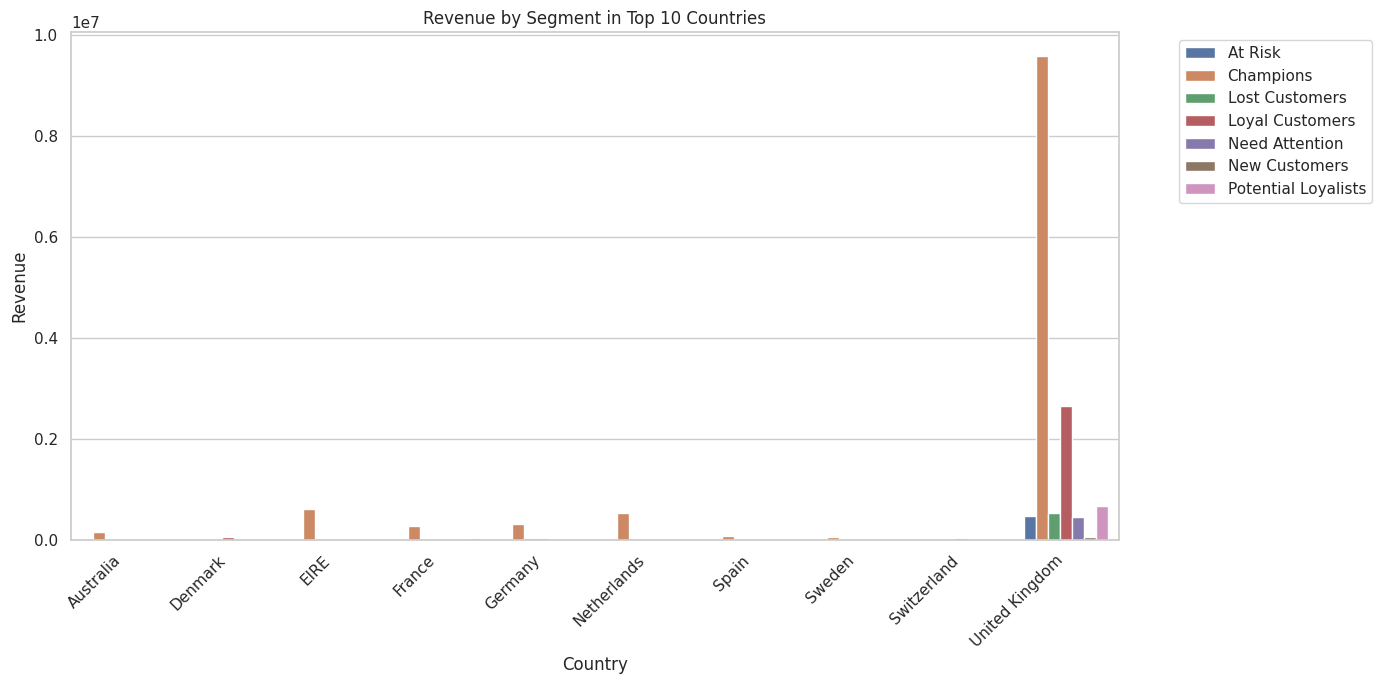

In [30]:
# Add country-level customer mapping based on most common customer country
customer_country = retail.groupby('customer_id')['country'].agg(lambda x: x.mode().iloc[0]).reset_index()
rfm_country = rfm.merge(customer_country, on='customer_id', how='left')

country_segment = (
    rfm_country.groupby(['country', 'segment'])
    .agg(customers=('customer_id', 'count'), revenue=('monetary', 'sum'))
    .reset_index()
)

# Top 10 countries by segmented revenue
top_countries = rfm_country.groupby('country')['monetary'].sum().sort_values(ascending=False).head(10).index
country_segment_top = country_segment[country_segment['country'].isin(top_countries)]

plt.figure(figsize=(14, 7))
sns.barplot(data=country_segment_top, x='country', y='revenue', hue='segment')
plt.title('Revenue by Segment in Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Insight: Country-Level Campaign Planning

The UK is the core market and should remain the priority for retention campaigns. International markets with meaningful revenue can be targeted with localized campaigns, especially for wholesale buyers and repeat customers.

## 13. Final Business Recommendations

### Recommendation 1: Protect High-Value Customers

LGS should prioritize Champions and Loyal Customers because they are likely to generate a high share of revenue. Recommended actions include VIP offers, early access to new giftware, exclusive wholesale pricing, and personalized account management.

### Recommendation 2: Reduce Churn with Re-Engagement Campaigns

At Risk customers should receive targeted reactivation emails with limited-time offers. These campaigns should focus on customers who previously purchased frequently or spent above average.

### Recommendation 3: Convert New Customers into Repeat Buyers

New Customers should receive onboarding campaigns that recommend popular products, best-selling bundles, and first-repeat-purchase incentives.

### Recommendation 4: Use Product Bundles to Increase Average Order Value

Top-selling products can be packaged into bundles for Loyal Customers and Potential Loyalists. This can increase basket size without requiring LGS to acquire new customers.

### Recommendation 5: Refresh Segments Regularly

RFM segmentation should not be a one-time analysis. LGS should refresh the segmentation weekly or monthly so that marketing campaigns stay current.

## 14. Production and Scaling Considerations

Although this is a PoC, the workflow can be scaled into a production-ready customer analytics pipeline.

### Future Improvements

1. **Automated ETL Pipeline**  
   Schedule data extraction, cleaning, and RFM calculation using tools such as Airflow or cron.

2. **CRM Integration**  
   Export segment labels to CRM or email marketing platforms for targeted campaigns.

3. **Weekly or Monthly Refresh**  
   Recalculate segments regularly to capture changing customer behaviour.

4. **Churn Prediction Model**  
   Use machine learning to predict which customers are likely to stop purchasing.

5. **Campaign Performance Tracking**  
   Track open rates, conversion rates, and revenue uplift by segment.

6. **Customer Lifetime Value Model**  
   Extend RFM analysis into customer lifetime value estimation for long-term planning.

## 15. Export Final Customer Segmentation Output

The final RFM table can be exported and shared with the marketing team. This file can be used as the starting point for email campaigns and CRM uploads.

In [31]:
# Export final customer segmentation file
rfm_output = rfm_country.copy()
rfm_output.to_csv('lgs_customer_rfm_segments.csv', index=False)

print('Export completed: lgs_customer_rfm_segments.csv')
rfm_output.head()

Export completed: lgs_customer_rfm_segments.csv


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score,segment,country
0,12346,326,12,"77,556.46",2,5,5,255,12,Loyal Customers,United Kingdom
1,12347,2,8,"4,921.53",5,4,5,545,14,Champions,Iceland
2,12348,75,5,"2,019.40",3,4,4,344,11,Loyal Customers,Finland
3,12349,19,4,"4,428.69",5,3,5,535,13,Potential Loyalists,Italy
4,12350,310,1,334.40,2,1,2,212,5,Lost Customers,Norway


## 16. Conclusion

This PoC shows how LGS can convert raw transaction data into actionable customer intelligence. RFM segmentation helps the marketing team identify which customers to retain, re-engage, nurture, and reward.

The main business value is that LGS can move from generic marketing campaigns to targeted, data-driven campaigns that improve customer retention, increase average order value, and support revenue growth.